In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import librosa.display
from pydub import AudioSegment
from IPython.display import Audio

from src.helper import *

sns.set_style(style="whitegrid")

In [2]:
#set config
DATA_PATH = "data/deep-detect/dataset/"

### Checking dataset count and filetypes

Key takeaways : 

- Train files contain 76.9k audio files. 54.2% real and 45.8% fake.
- Train real samples are 100% .wav files, while the fake samples are 67.2% .mp3 and 32.8% .wav files.
- Need to be careful in feature extraction to make sure no bias exists between the two file types.
- Testing files contain 11.7k audio files. 59.6% real and 40.4% fake. 
- Testing files are 100% .wav files.
- Holdout files contain 14.4k .wav files.
- It seems like there are some distinct audio file sources shown by the prefix: file, itw, or train/dev_ami

In [3]:
folders_list = get_subfolders(DATA_PATH)
folders_list

['holdout',
 'testing',
 'testing/fake',
 'testing/real',
 'training',
 'training/fake',
 'training/real']

In [4]:
for folder in folders_list:
    path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(path):
        print(f"⚠️  Folder not found: {folder}")
        continue

    count, prefix_counter, ext_counter = get_file_stats(path)

    print(f"\n📂 Folder: {folder}. Total files: {count}.")
    prefix_str = [f"{num} x {prefix}" for prefix, num in prefix_counter.items()]
    print(f"Prefixes : {', '.join(prefix_str)}")
    ext_str = [f"{num} x {ext}" for ext, num in ext_counter.items()]
    print(f"Extensions : {', '.join(ext_str)}")


📂 Folder: holdout. Total files: 14397.
Prefixes : 14397 x audio_
Extensions : 14397 x wav

📂 Folder: testing. Total files: 11710.
Prefixes : 4634 x file, 6355 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 11710 x wav

📂 Folder: testing/fake. Total files: 4733.
Prefixes : 2370 x file, 2363 x itw
Extensions : 4733 x wav

📂 Folder: testing/real. Total files: 6977.
Prefixes : 2264 x file, 3992 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 6977 x wav

📂 Folder: training. Total files: 76943.
Prefixes : 53882 x file, 22245 x itw, 244 x dev_ami_ib_h_mio__, 309 x dev_ami_ib_sdm_mio__, 195 x dev_ami_ib_h_fie__, 68 x dev_ami_ib_h_fio__
Extensions : 23678 x mp3, 53265 x 

### Looking at sample audio files

Key takeaways : 
- Audio samples seem to consist of a few seconds of spoken words

In [5]:
sample_wav = os.path.join(DATA_PATH, "training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav")
sample_mp3 = os.path.join(DATA_PATH, "training/fake/file3.mp3")

audio_samples = [sample_wav, sample_mp3]

Loaded data/deep-detect/dataset/training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav
Sample rate: 16000
Duration: 3.30 seconds
Shape of waveform: (52800,)


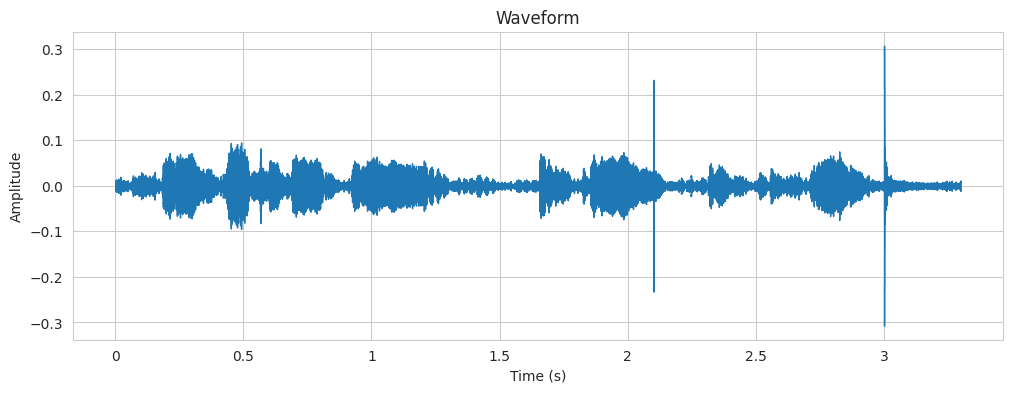

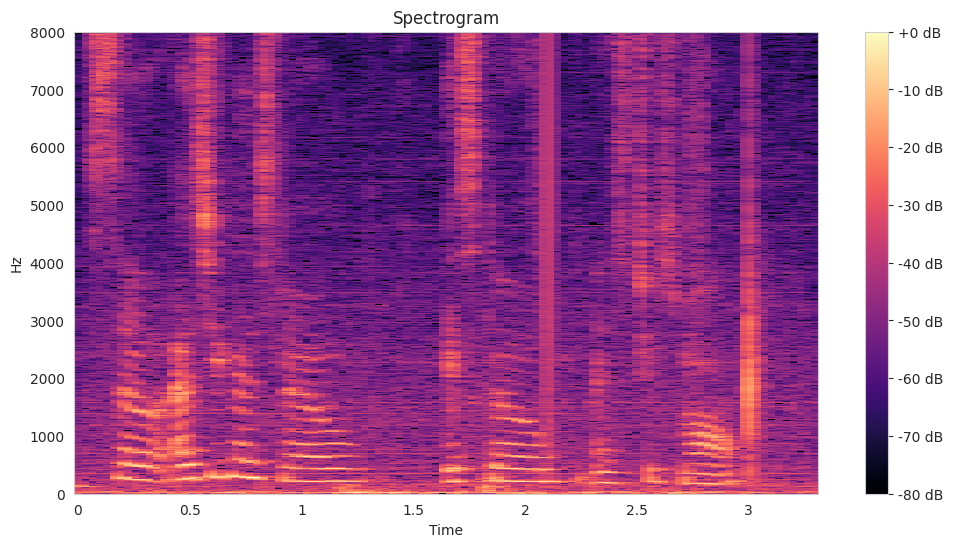

Channels: 1
Frame rate: 16000
Sample width: 4
Length (ms): 3300
Loaded data/deep-detect/dataset/training/fake/file3.mp3
Sample rate: 22050
Duration: 1.59 seconds
Shape of waveform: (35136,)


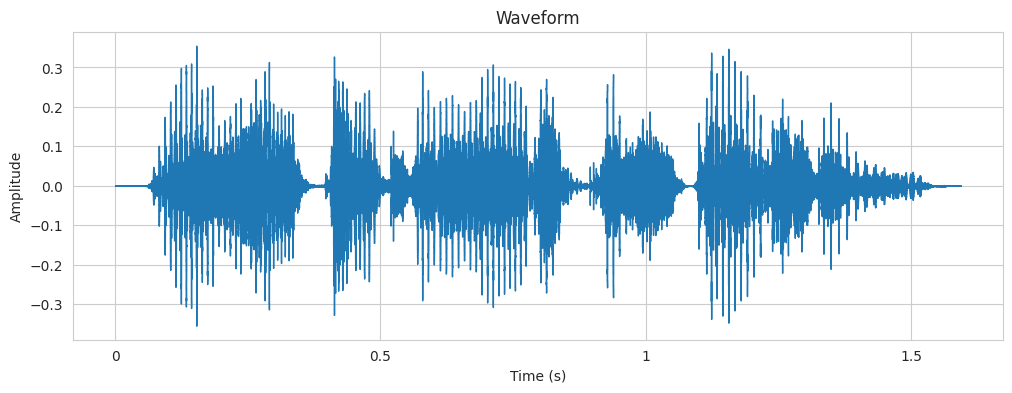

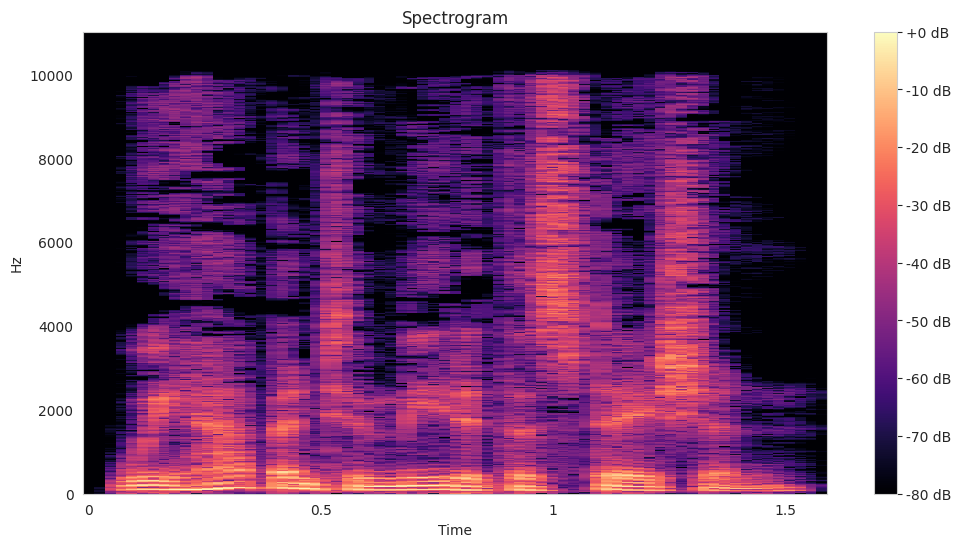

Channels: 1
Frame rate: 22050
Sample width: 2
Length (ms): 1593


In [6]:
for sample in audio_samples:
    # ---------- LOAD AUDIO ----------
    print('='*100)
    y, sr = librosa.load(sample, sr=None)  # waveform and sample rate
    print(f"Loaded {sample}")
    print(f"Sample rate: {sr}")
    print(f"Duration: {len(y)/sr:.2f} seconds")
    print(f"Shape of waveform: {y.shape}")

    # ---------- VISUALIZE WAVEFORM ----------
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    # ---------- SPECTROGRAM ----------
    D = np.abs(librosa.stft(y))
    DB = librosa.amplitude_to_db(D, ref=np.max)

    plt.figure(figsize=(12, 6))
    librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")
    plt.show()

    # ---------- METADATA (with pydub) ----------
    audio = AudioSegment.from_file(sample)
    print(f"Channels: {audio.channels}")
    print(f"Frame rate: {audio.frame_rate}")
    print(f"Sample width: {audio.sample_width}")
    print(f"Length (ms): {len(audio)}")

In [7]:
# ---------- PLAY AUDIO ----------
Audio(sample_wav)  # plays the file

In [8]:
# ---------- PLAY AUDIO ----------
Audio(sample_mp3)  # plays the file

### Extracting simple audio feature distributions of train and test

Key takeaways : 

- Some training files that are labeled fake is failed to be read by librosa

In [9]:
# ---------- COLLECT FILES ----------
records = []

for split in ["testing", "training"]:
    for label in ["real", "fake"]:
        folder = os.path.join(DATA_PATH, split, label)
        if not os.path.exists(folder):
            continue
        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            if os.path.isfile(fpath):
                name, ext = os.path.splitext(fpath)
                prefix = ''.join(ch for ch in name if not ch.isdigit())
                ext = ext.lower().lstrip(".")
                
                features = extract_audio_features(fpath)
                
                record = {
                    "filepath": fpath,
                    "filename": fname,
                    "extension": ext,
                    "prefix": prefix,
                    "split": split,
                    "label": label
                }
                record.update(features)
                records.append(record)

# ---------- TO DATAFRAME ----------
df = pd.DataFrame(records)

# ---------- SUMMARY ----------
print(df.head())
print(f"\nTotal files: {len(df)}")
print(df.groupby(["split", "label"]).size())

Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.
/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file16643.mp3: 


/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file27839.mp3: 
Error loading data/deep-detect/dataset/training/fake/file32972.mp3: 


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


...

Error loading data/deep-detect/dataset/training/fake/file9875.mp3: 
Error loading data/deep-detect/dataset/training/fake/file15746.mp3: 


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 50.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


Error loading data/deep-detect/dataset/training/fake/file31017.mp3: 


/home/ardacandra/Documents/Repos/deepdetect_audio_deepfake_detection_challenge/src/helper.py:43: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(filepath, sr=None)  # keep original sample rate
/home/ardacandra/miniconda3/envs/deepdetect_audio_deepfake_detection_challenge/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error loading data/deep-detect/dataset/training/fake/file17407.mp3: 
Error loading data/deep-detect/dataset/training/fake/file27206.mp3: 
Error loading data/deep-detect/dataset/training/fake/file27643.mp3: 
Error loading data/deep-detect/dataset/training/fake/file17450.mp3: 
Error loading data/deep-detect/dataset/training/fake/file5323.mp3: 
Error loading data/deep-detect/dataset/training/fake/file13424.mp3: 
Error loading data/deep-detect/dataset/training/fake/file30959.mp3: 
                                            filepath      filename extension  \
0  data/deep-detect/dataset/testing/real/file542.wav   file542.wav       wav   
1  data/deep-detect/dataset/testing/real/file671.wav   file671.wav       wav   
2   data/deep-detect/dataset/testing/real/itw735.wav    itw735.wav       wav   
3  data/deep-detect/dataset/testing/real/file1169...  file1169.wav       wav   
4  data/deep-detect/dataset/testing/real/itw18571...  itw18571.wav       wav   

                                     

In [ ]:
#fix prefix to exclude the folder paths
df['prefix'] = df['prefix'].apply(lambda x:x.split("/")[-1])

In [19]:
print(df.shape)
print(df.columns)
df.head(3)

(88653, 11)
Index(['filepath', 'filename', 'extension', 'prefix', 'split', 'label',
       'duration', 'sample_rate', 'rms_energy', 'zero_crossing_rate',
       'spectral_centroid'],
      dtype='object')


,filepath,filename,extension,prefix,split,label,duration,sample_rate,rms_energy,zero_crossing_rate,spectral_centroid
0,data/deep-detect/dataset/testing/real/file542.wav,file542.wav,wav,file,testing,real,3.375062,16000.0,0.078996,0.123070,1678.634801
1,data/deep-detect/dataset/testing/real/file671.wav,file671.wav,wav,file,testing,real,2.095063,16000.0,0.103099,0.150442,1928.962536
2,data/deep-detect/dataset/testing/real/itw735.wav,itw735.wav,wav,itw,testing,real,1.245062,16000.0,0.041119,0.059295,1039.774261


In [20]:
if not os.path.exists("output"):
    os.mkdir("output")

df.to_csv("output/nb_00__train_test_audio_feats.csv", index=False)

### EDA of basic audio features per split/label/extension/prefix groups

Key takeaways:
- Clear duration differences in real vs fake samples. Fake samples tends to have shorter duration. Real samples show a significant duration distribution difference between train and test split.
- Real samples are more likely to have extreme values in terms of RMS energy (loudness measure).
- Real samples also tends to have a larger spread in terms of zero crossing rate, showing that its more noisy.
- Train mp3 files are all fake and showing a clear difference in characteristics compared to wav files.
- Different file prefixes (e.g. itw, file) also show clear difference in characteristics, likely to have been extracted from different sources. 

In [3]:
df = pd.read_csv("output/nb_00__train_test_audio_feats.csv")
df = df.sort_values('label', ascending=True).reset_index(drop=True)
print(df.shape)
df.head(3)

(88653, 11)


,filepath,filename,extension,prefix,split,label,duration,sample_rate,rms_energy,zero_crossing_rate,spectral_centroid
0,data/deep-detect/dataset/training/fake/file106...,file10645.mp3,mp3,file,training,fake,1.593469,22050.0,0.069644,0.090757,1772.432130
1,data/deep-detect/dataset/training/fake/file163...,file16352.mp3,mp3,file,training,fake,3.204000,16000.0,0.062437,0.134364,1614.289062
2,data/deep-detect/dataset/training/fake/itw1636...,itw16367.wav,wav,itw,training,fake,10.295000,16000.0,0.017932,0.171338,1807.889181


In [4]:
# Features to summarize
feature_cols = ["duration", "sample_rate", "rms_energy", "zero_crossing_rate", "spectral_centroid"]

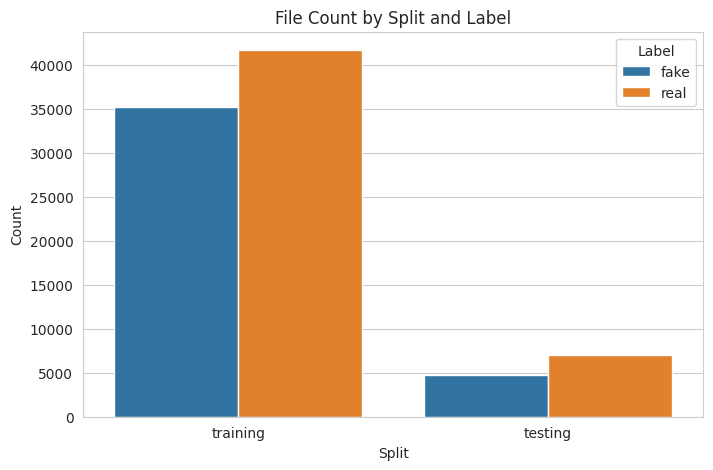

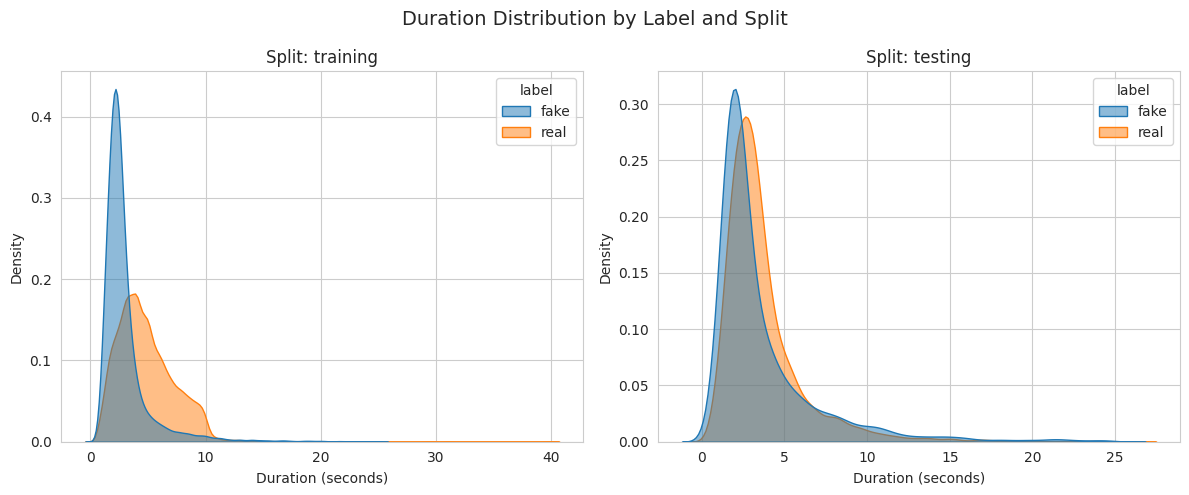

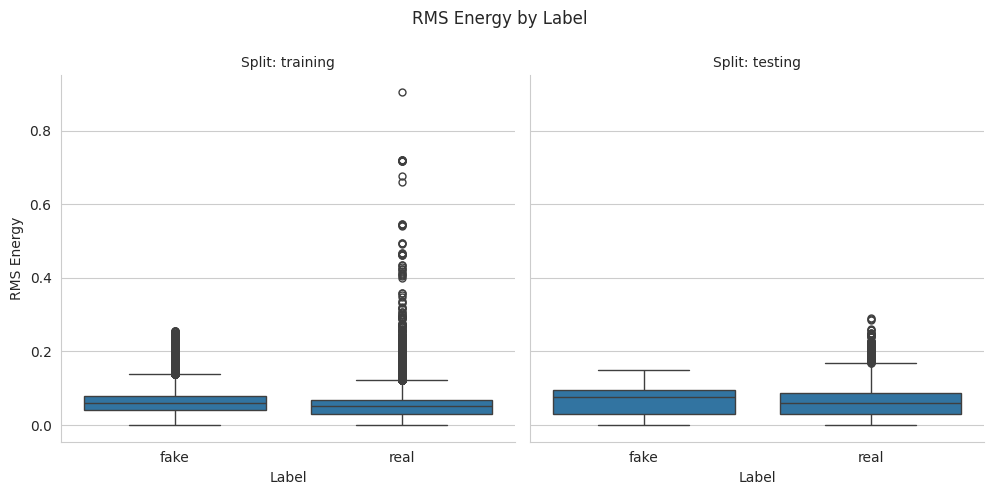

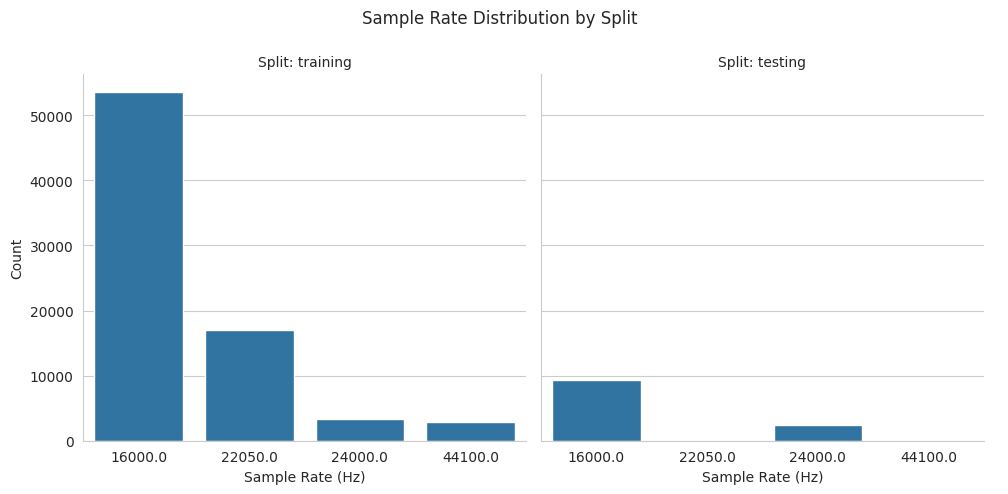

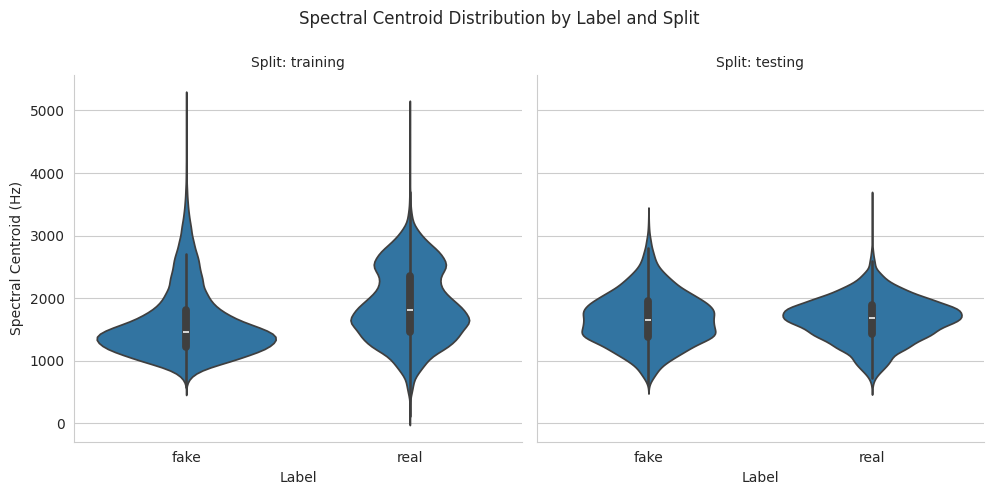

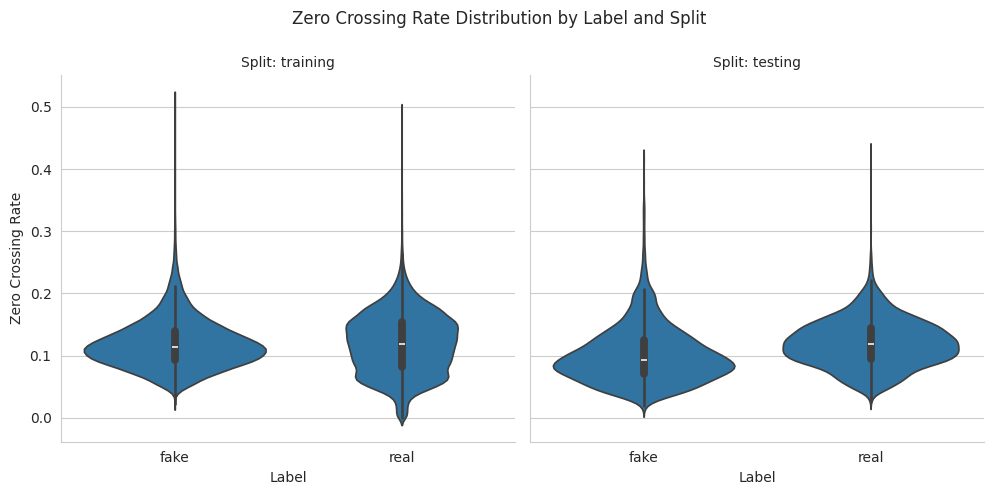

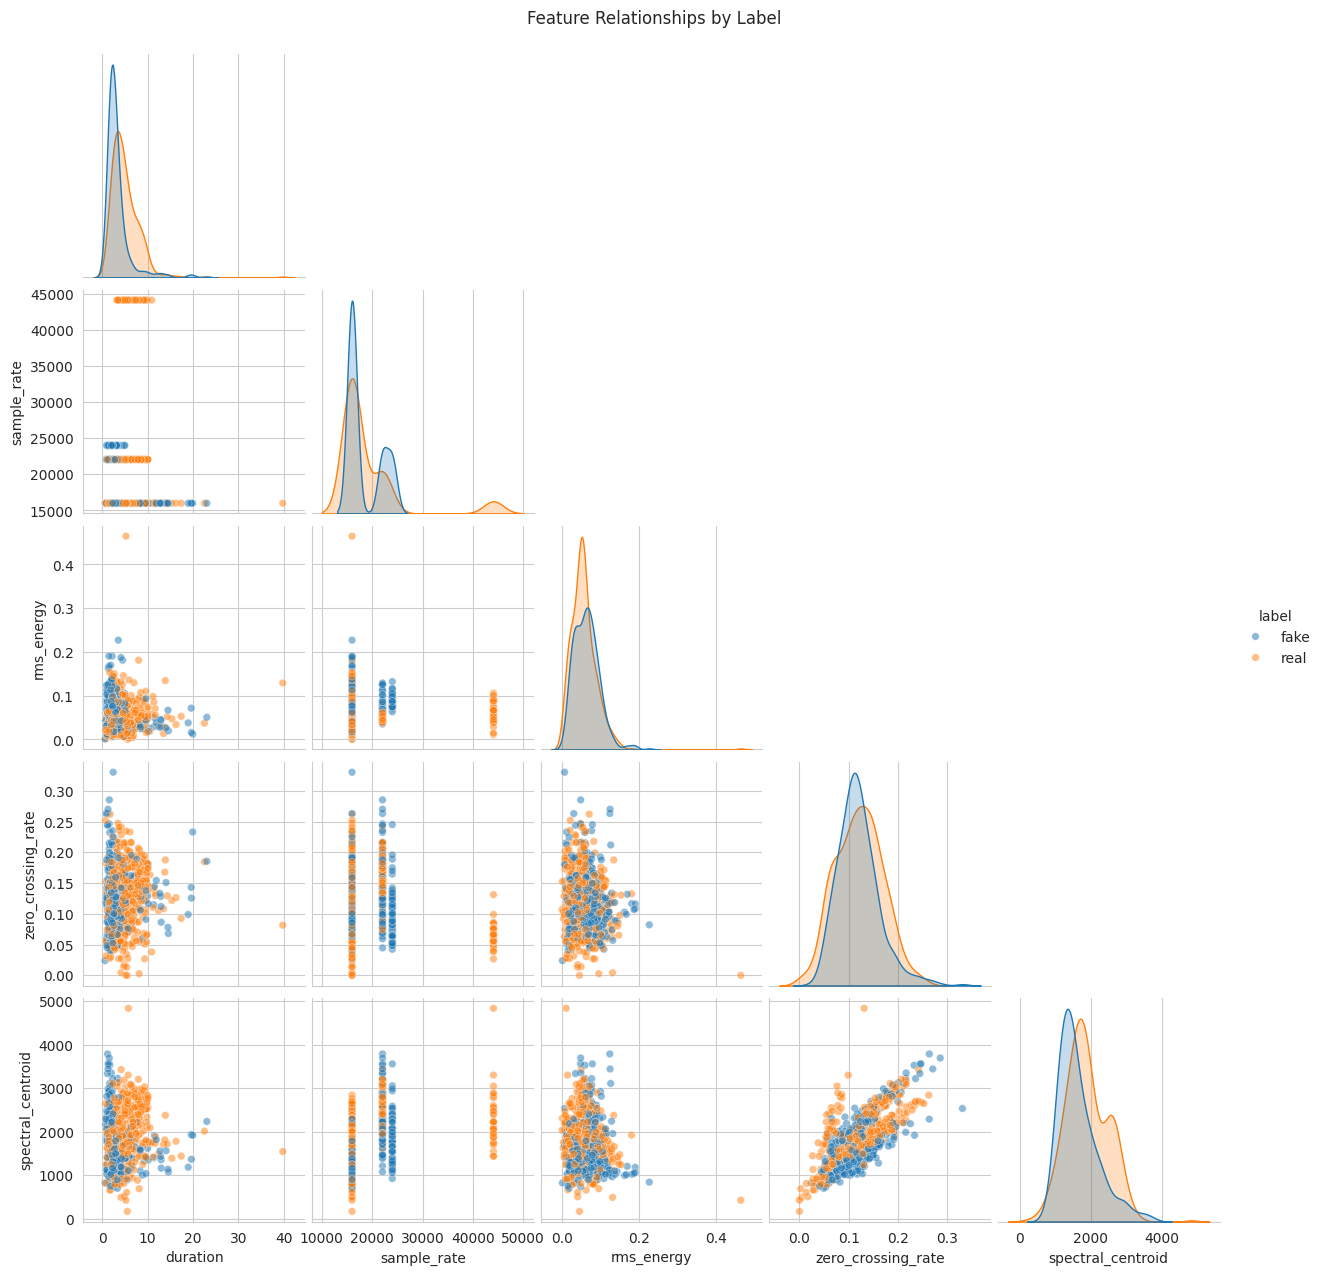

In [13]:
# ---------- 1. Count of files by split + label ----------
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="split", hue="label")
plt.title("File Count by Split and Label")
plt.xlabel("Split")
plt.ylabel("Count")
plt.legend(title="Label")
plt.show()

# ---------- 2. Distribution of duration ----------

# Unique splits
splits = df["split"].unique()

# Create one subplot per split
fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 5), sharex=False, sharey=False)

# If only one split, axes is not an array
if len(splits) == 1:
    axes = [axes]

# Plot duration distributions per split
for ax, split in zip(axes, splits):
    subset = df[df["split"] == split]
    sns.kdeplot(
        data=subset,
        x="duration",
        hue="label",
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"Split: {split}")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Density")

fig.suptitle("Duration Distribution by Label and Split", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 3. RMS energy boxplots ----------
g = sns.catplot(
    data=df,
    x="label",
    y="rms_energy",
    kind="box",
    col="split",
    height=5,
    aspect=1
)
g.set_titles("Split: {col_name}")
g.set_axis_labels("Label", "RMS Energy")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("RMS Energy by Label")
plt.show()

# ---------- 4. Sample rate counts ----------
g = sns.catplot(
    data=df,
    x="sample_rate",
    kind="count",
    col="split",
    height=5,
    aspect=1
)
g.set_titles("Split: {col_name}")
g.set_axis_labels("Sample Rate (Hz)", "Count")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("Sample Rate Distribution by Split")
plt.show()

# ---------- 5. Spectral centroid comparison ----------
g = sns.catplot(
    data=df,
    x="label",
    y="spectral_centroid",
    kind="violin",
    col="split",
    height=5,
    aspect=1
)
g.set_titles("Split: {col_name}")
g.set_axis_labels("Label", "Spectral Centroid (Hz)")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("Spectral Centroid Distribution by Label and Split")
plt.show()

# ---------- 6. Zero crossing rate comparison ----------
g = sns.catplot(
    data=df,
    x="label",
    y="zero_crossing_rate",
    kind="violin",
    col="split",
    height=5,
    aspect=1
)
g.set_titles("Split: {col_name}")
g.set_axis_labels("Label", "Zero Crossing Rate")
plt.subplots_adjust(top=0.85)
g.figure.suptitle("Zero Crossing Rate Distribution by Label and Split")
plt.show()

# ---------- 7. Pairplot of features ----------
sns.pairplot(
    df.sample(min(len(df), 1000), random_state=42),  # sample if large
    vars=feature_cols,
    hue="label",
    corner=True,
    plot_kws=dict(alpha=0.5, s=30)
)
plt.suptitle("Feature Relationships by Label", y=1.02)
plt.show()

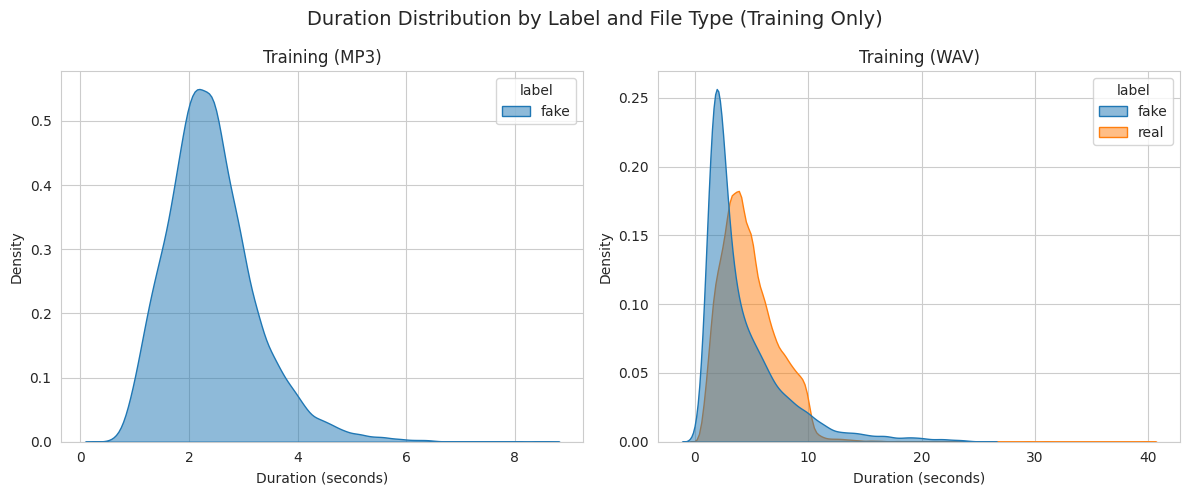

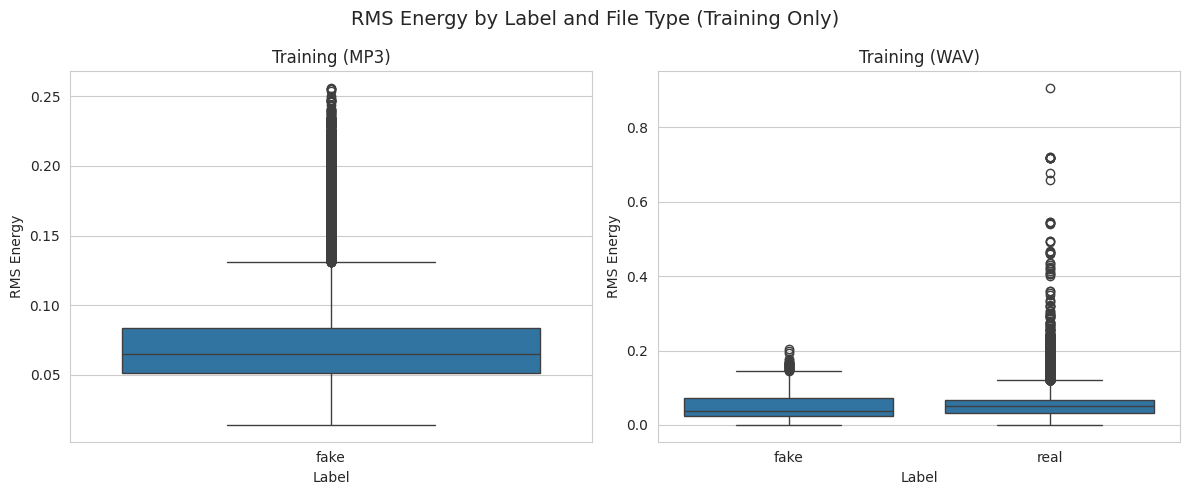

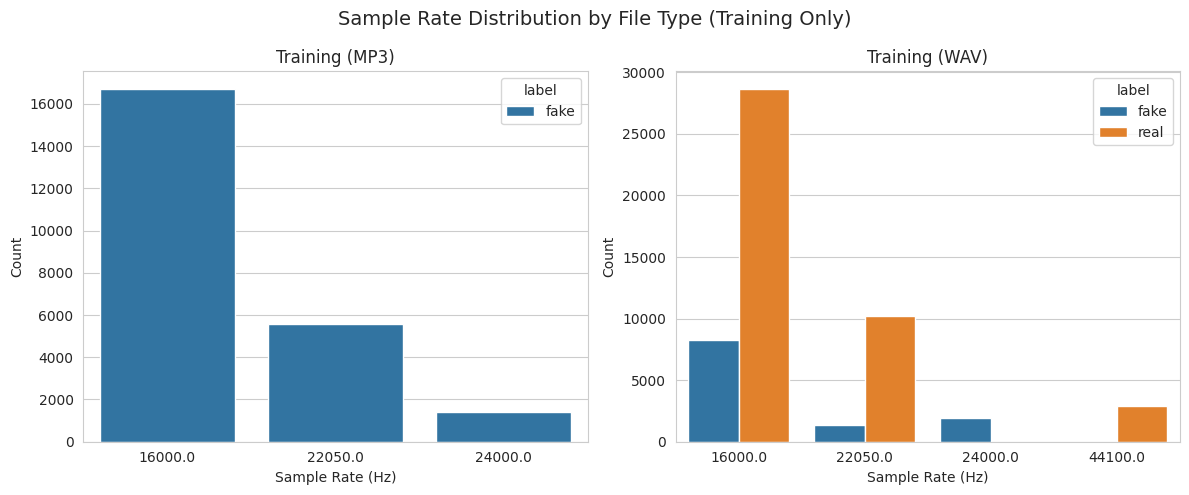

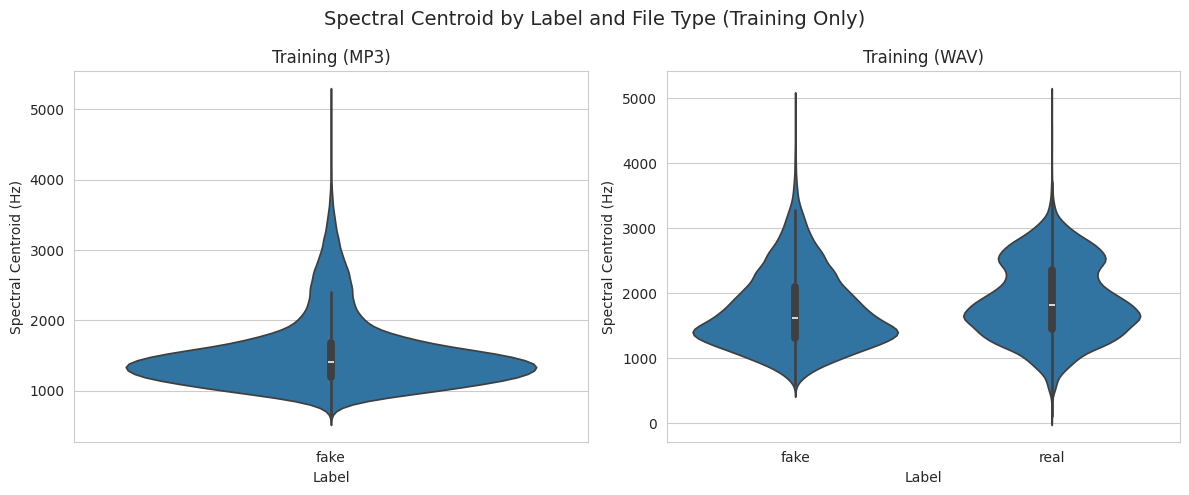

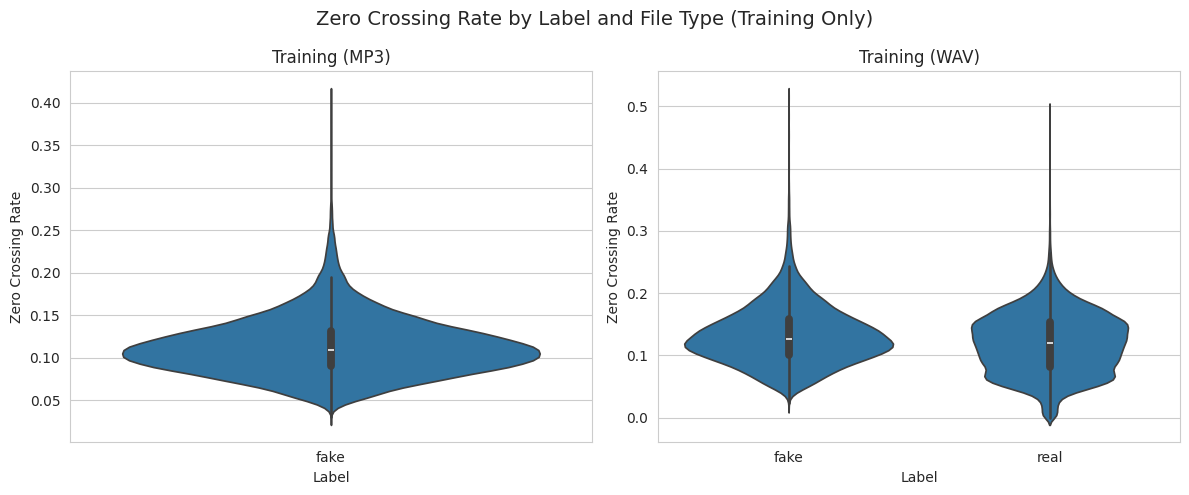

In [14]:
# Filter only training files
df_train = df[df["split"] == "training"]

# Unique file extensions (e.g. .wav, .mp3)
filetypes = df_train["extension"].unique()

# ---------- 1. Duration distributions ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharex=False, sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, ext in zip(axes, filetypes):
    subset = df_train[df_train["extension"] == ext]
    sns.kdeplot(
        data=subset,
        x="duration",
        hue="label",
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"Training ({ext.upper()})")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Density")

fig.suptitle("Duration Distribution by Label and File Type (Training Only)", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 2. RMS Energy boxplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, ext in zip(axes, filetypes):
    subset = df_train[df_train["extension"] == ext]
    sns.boxplot(data=subset, x="label", y="rms_energy", ax=ax)
    ax.set_title(f"Training ({ext.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("RMS Energy")

fig.suptitle("RMS Energy by Label and File Type (Training Only)", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 3. Sample rate counts ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, ext in zip(axes, filetypes):
    subset = df_train[df_train["extension"] == ext]
    sns.countplot(data=subset, x="sample_rate", hue="label", ax=ax)
    ax.set_title(f"Training ({ext.upper()})")
    ax.set_xlabel("Sample Rate (Hz)")
    ax.set_ylabel("Count")

fig.suptitle("Sample Rate Distribution by File Type (Training Only)", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 4. Spectral centroid violinplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, ext in zip(axes, filetypes):
    subset = df_train[df_train["extension"] == ext]
    sns.violinplot(data=subset, x="label", y="spectral_centroid", ax=ax)
    ax.set_title(f"Training ({ext.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("Spectral Centroid (Hz)")

fig.suptitle("Spectral Centroid by Label and File Type (Training Only)", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 5. Zero crossing rate violinplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, ext in zip(axes, filetypes):
    subset = df_train[df_train["extension"] == ext]
    sns.violinplot(data=subset, x="label", y="zero_crossing_rate", ax=ax)
    ax.set_title(f"Training ({ext.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("Zero Crossing Rate")

fig.suptitle("Zero Crossing Rate by Label and File Type (Training Only)", fontsize=14)
plt.tight_layout()
plt.show()


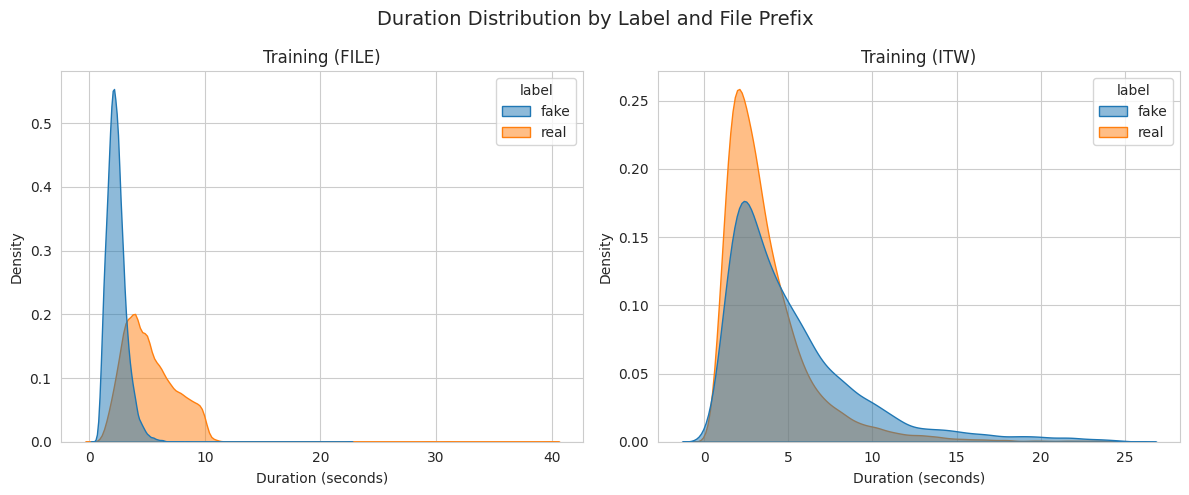

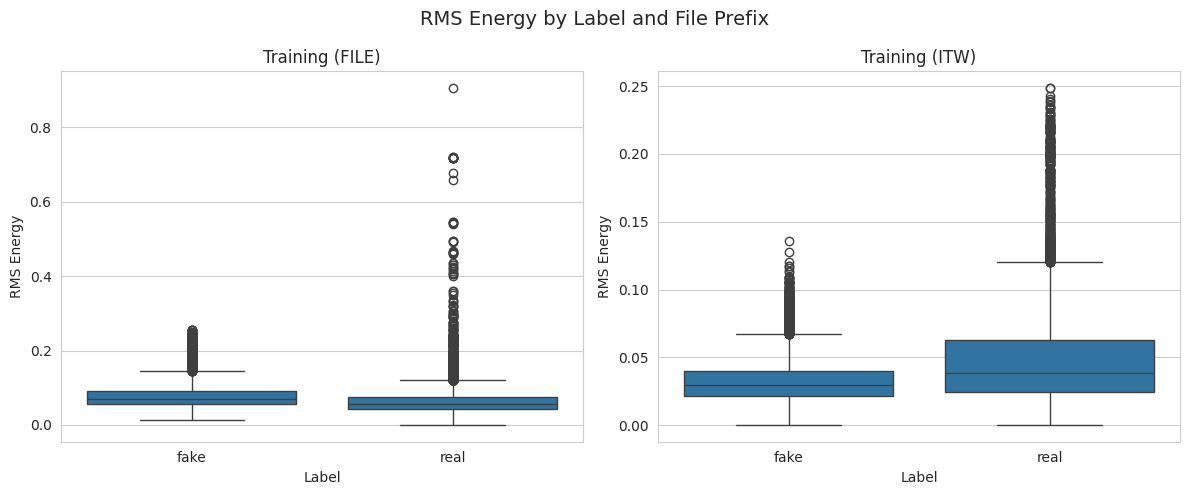

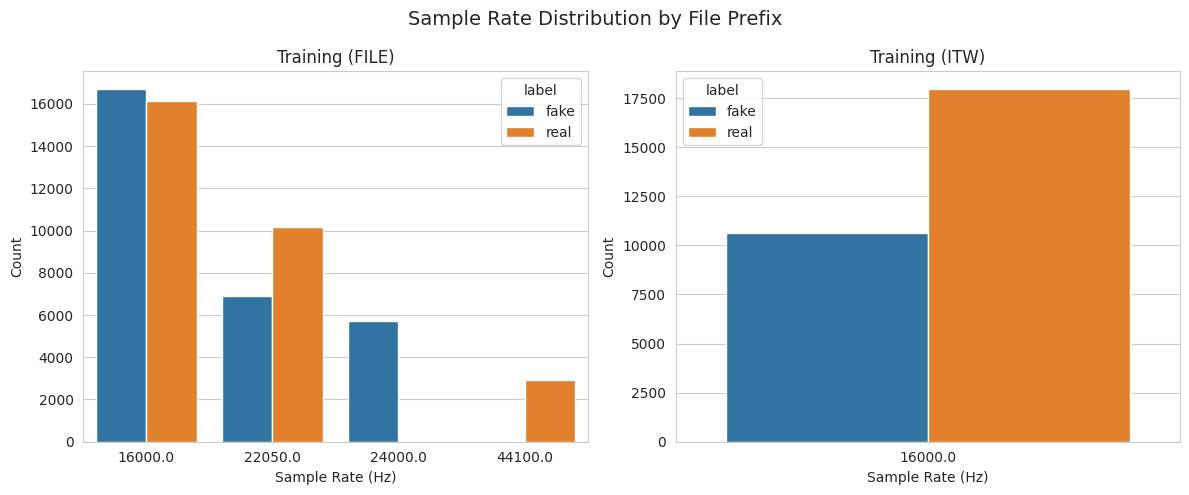

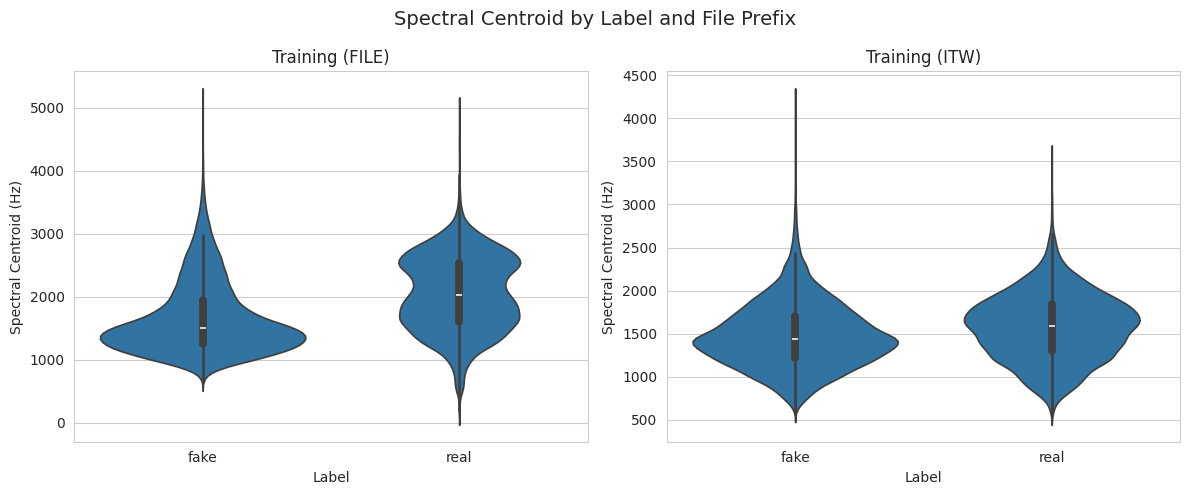

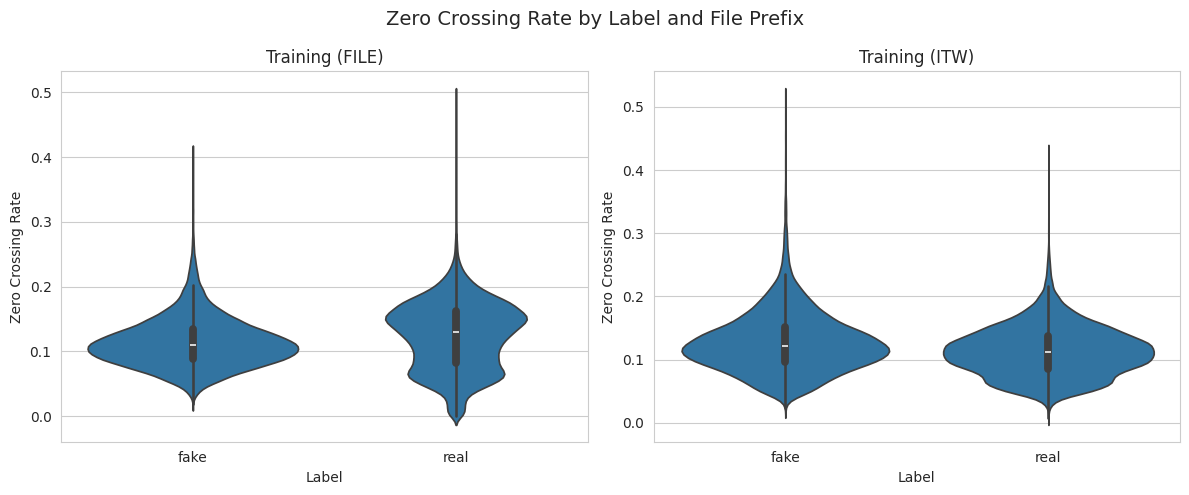

In [5]:
# Check two prefix types
filetypes = ['file', 'itw']

# ---------- 1. Duration distributions ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharex=False, sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, prefix in zip(axes, filetypes):
    subset = df[df["prefix"] == prefix]
    sns.kdeplot(
        data=subset,
        x="duration",
        hue="label",
        fill=True,
        common_norm=False,
        alpha=0.5,
        ax=ax
    )
    ax.set_title(f"Training ({prefix.upper()})")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Density")

fig.suptitle("Duration Distribution by Label and File Prefix", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 2. RMS Energy boxplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, prefix in zip(axes, filetypes):
    subset = df[df["prefix"] == prefix]
    sns.boxplot(data=subset, x="label", y="rms_energy", ax=ax)
    ax.set_title(f"Training ({prefix.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("RMS Energy")

fig.suptitle("RMS Energy by Label and File Prefix", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 3. Sample rate counts ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, prefix in zip(axes, filetypes):
    subset = df[df["prefix"] == prefix]
    sns.countplot(data=subset, x="sample_rate", hue="label", ax=ax)
    ax.set_title(f"Training ({prefix.upper()})")
    ax.set_xlabel("Sample Rate (Hz)")
    ax.set_ylabel("Count")

fig.suptitle("Sample Rate Distribution by File Prefix", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 4. Spectral centroid violinplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, prefix in zip(axes, filetypes):
    subset = df[df["prefix"] == prefix]
    sns.violinplot(data=subset, x="label", y="spectral_centroid", ax=ax)
    ax.set_title(f"Training ({prefix.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("Spectral Centroid (Hz)")

fig.suptitle("Spectral Centroid by Label and File Prefix", fontsize=14)
plt.tight_layout()
plt.show()


# ---------- 5. Zero crossing rate violinplots ----------
fig, axes = plt.subplots(1, len(filetypes), figsize=(6 * len(filetypes), 5), sharey=False)
if len(filetypes) == 1:
    axes = [axes]

for ax, prefix in zip(axes, filetypes):
    subset = df[df["prefix"] == prefix]
    sns.violinplot(data=subset, x="label", y="zero_crossing_rate", ax=ax)
    ax.set_title(f"Training ({prefix.upper()})")
    ax.set_xlabel("Label")
    ax.set_ylabel("Zero Crossing Rate")

fig.suptitle("Zero Crossing Rate by Label and File Prefix", fontsize=14)
plt.tight_layout()
plt.show()


In [6]:
# ---------- Grouped Summary Statistics ----------
# By split + label
summary_split_label = df.groupby(["split", "label"])[feature_cols].agg(["mean", "std", "min", "max", "count"])
print("\n=== Summary by Split + Label ===")
display(summary_split_label)

# By extension
summary_extension = df.groupby("extension")[feature_cols].agg(["mean", "std", "min", "max", "count"])
print("\n=== Summary by Extension ===")
display(summary_extension)

# By prefix
prefix_counts = df["prefix"].value_counts().index
summary_prefix = df[df["prefix"].isin(prefix_counts)].groupby("prefix")[feature_cols].agg(["mean", "std", "min", "max", "count"])
print("\n=== Summary by Prefix ===")
display(summary_prefix)


=== Summary by Split + Label ===


duration                                         sample_rate  \
                    mean       std       min        max  count          mean   
split    label                                                                 
testing  fake   3.678150  3.347771  0.645000  24.991000   4733  20005.915910   
         real   3.714166  2.578576  0.543000  26.169937   6977  16000.000000   
training fake   3.027899  2.367609  0.417959  24.971062  35198  17942.394454   
         real   4.843574  2.518017  0.438063  39.808000  41731  19430.425823   

                                                      ... zero_crossing_rate  \
                        std      min      max  count  ...               mean   
split    label                                        ...                      
testing  fake   4000.418257  16000.0  24000.0   4733  ...           0.101559   
         real      0.000000  16000.0  16000.0   6977  ...           0.120257   
training fake   3075.360255  16000.0  24000.0  35198  ...           0.119359   
         real   7218.373798  16000.0  44100.0  41731  ...           0.118940   

                                                    spectral_centroid  \
                     std       min       max  count              mean   
split    label                                                          
testing  fake   0.045700  0.018579  0.414510   4733       1678.122039   
         real   0.037999  0.027239  0.428604   6977       1661.114307   
training fake   0.039900  0.022854  0.514811  35198       1600.022478   
         real   0.048962  0.000000  0.492914  41731       1893.947117   

                                                            
                       std         min          max  count  
split    label                                              
testing  fake   420.241979  633.798809  3293.972849   4733  
         real   354.604670  582.834036  3578.184228   6977  
training fake   547.026395  590.417312  5165.415615  35198  
         real   591.397213  115.976043  5014.260409  41731  

[4 rows x 25 columns]


=== Summary by Extension ===


duration                                         sample_rate  \
               mean       std       min        max  count          mean   
extension                                                                 
mp3        2.415592  0.826891  0.417959   8.489796  23664  17895.288201   
wav        4.538099  2.858551  0.438063  39.808000  64975  18856.997307   

                                                 ... zero_crossing_rate  \
                   std      min      max  count  ...               mean   
extension                                        ...                      
mp3        2966.086465  16000.0  24000.0  23664  ...           0.113111   
wav        6152.215561  16000.0  44100.0  64975  ...           0.120165   

                                               spectral_centroid              \
                std       min       max  count              mean         std   
extension                                                                      
mp3        0.034342  0.030021  0.407975  23664       1529.229869  510.734228   
wav        0.047834  0.000000  0.514811  64975       1826.831071  566.707005   

                                           
                  min          max  count  
extension                                  
mp3        650.485760  5165.415615  23664  
wav        115.976043  5014.260409  64975  

[2 rows x 25 columns]


=== Summary by Prefix ===


duration                                        \
                            mean       std       min        max  count   
prefix                                                                   
dev_ami_ib_h_fie__      5.187949  1.524824  3.120000  11.190000    195   
dev_ami_ib_h_fio__      5.597500  2.220569  3.200000  11.710000     68   
dev_ami_ib_h_mio__      5.993689  1.986924  3.100000  14.140000    244   
dev_ami_ib_sdm_mio__    6.164822  1.921597  3.190000  12.550000    309   
dev_ami_isb_h_fie__     5.632603  2.477561  1.990000  13.700000    123   
dev_ami_isb_h_mie__     4.845000  1.824742  2.050000  10.020000     46   
dev_ami_isb_h_mio__     4.700824  2.166826  2.000000  10.820000     85   
eval_ami_isb_h_fio__    8.216099  4.177009  3.230000  26.169937    141   
eval_ami_isb_sdm_fie__  7.448967  2.863703  3.300000  16.530000     58   
file                    3.765207  2.198177  0.417959  39.808000  58502   
itw                     4.285823  3.348957  0.438063  24.991000  28600   
train_ami_isc_h_mie__   5.502922  2.576787  2.750000  18.030000    243   
train_ami_isc_h_mio__   7.051600  4.060239  3.290000  20.410000     25   

                         sample_rate                                        \
                                mean          std      min      max  count   
prefix                                                                       
dev_ami_ib_h_fie__      16000.000000     0.000000  16000.0  16000.0    195   
dev_ami_ib_h_fio__      16000.000000     0.000000  16000.0  16000.0     68   
dev_ami_ib_h_mio__      16000.000000     0.000000  16000.0  16000.0    244   
dev_ami_ib_sdm_mio__    16000.000000     0.000000  16000.0  16000.0    309   
dev_ami_isb_h_fie__     16000.000000     0.000000  16000.0  16000.0    123   
dev_ami_isb_h_mie__     16000.000000     0.000000  16000.0  16000.0     46   
dev_ami_isb_h_mio__     16000.000000     0.000000  16000.0  16000.0     85   
eval_ami_isb_h_fio__    16000.000000     0.000000  16000.0  16000.0    141   
eval_ami_isb_sdm_fie__  16000.000000     0.000000  16000.0  16000.0     58   
file                    19939.754196  6371.274162  16000.0  44100.0  58502   
itw                     16000.000000     0.000000  16000.0  16000.0  28600   
train_ami_isc_h_mie__   16000.000000     0.000000  16000.0  16000.0    243   
train_ami_isc_h_mio__   16000.000000     0.000000  16000.0  16000.0     25   

                        ... zero_crossing_rate                                \
                        ...               mean       std       min       max   
prefix                  ...                                                    
dev_ami_ib_h_fie__      ...           0.104220  0.023156  0.045287  0.168002   
dev_ami_ib_h_fio__      ...           0.096140  0.017407  0.062547  0.152055   
dev_ami_ib_h_mio__      ...           0.087052  0.019812  0.046863  0.155680   
dev_ami_ib_sdm_mio__    ...           0.099315  0.020598  0.054054  0.184168   
dev_ami_isb_h_fie__     ...           0.128277  0.024754  0.077095  0.194911   
dev_ami_isb_h_mie__     ...           0.100443  0.020432  0.061568  0.148617   
dev_ami_isb_h_mio__     ...           0.091667  0.026621  0.050998  0.210591   
eval_ami_isb_h_fio__    ...           0.107403  0.018768  0.051173  0.167486   
eval_ami_isb_sdm_fie__  ...           0.105746  0.023480  0.043563  0.185286   
file                    ...           0.118729  0.045857  0.000000  0.492914   
itw                     ...           0.118258  0.043074  0.007891  0.514811   
train_ami_isc_h_mie__   ...           0.106175  0.026484  0.048419  0.199970   
train_ami_isc_h_mio__   ...           0.091887  0.017738  0.066735  0.145211   

                              spectral_centroid                           \
                        count              mean         std          min   
prefix                                                                     
dev_ami_ib_h_fie__        195       1768.254282  223.438160  1202.449423   
dev_a